# Final Optuna LGBM

Run the final `Optuna` tuning after the data-side experiments are fixed. The notebook uses the best sparsity threshold found in `05_sparsity_thresholds_lgbm.ipynb`.

In [1]:
import sys

sys.path.append("../")

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

/Users/ayeustsihneyeu/ml_/santander/.santander/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from lightgbm import early_stopping, log_evaluation
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error, root_mean_squared_log_error
from sklearn.model_selection import KFold, train_test_split

from src.preprocessing import FeaturePreprocessor
from src.loader import Loader
from src.metrics import format_metric_value
from src.modeling import build_lgbm_regressor

In [3]:
SEED = 42
TEST_SIZE = 0.33
CV = 5
N_TRIALS = 50
EARLY_STOPPING_ROUNDS = 100
SPARSITY_THRESHOLD = 0.9875

## Load Data

In [4]:
loader = Loader()
df = loader.load("../data/processed_data.csv")
df.shape

(4459, 4732)

In [5]:
X = df.drop(columns="target")
y = df["target"]
y_log = np.log1p(y)

(X.shape, y.shape)

((4459, 4731), (4459,))

## Fixed Data Setup

In [6]:
SPARSITY_THRESHOLD

0.9875

In [7]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw, y_train_log, y_test_log = train_test_split(
    X,
    y,
    y_log,
    test_size=TEST_SIZE,
    random_state=SEED,
)

cv = KFold(n_splits=CV, shuffle=True, random_state=SEED)

## Optuna Search

The objective optimizes RMSE in log-space, which is equivalent to `RMSLE` for the `log1p(target)` setup. Sparse filtering is fitted inside each fold only on that fold's training data.

In [8]:
def suggest_params(trial: optuna.Trial) -> dict:
    return {
        "n_estimators": trial.suggest_int("n_estimators", 500, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 0.003, 0.03, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 8, 64),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 160),
        "subsample": trial.suggest_float("subsample", 0.55, 0.95),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 7),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.35, 0.85),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 50.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 50.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
    }

In [9]:
def objective(trial: optuna.Trial) -> float:
    params = suggest_params(trial)
    fold_scores = []
    best_iterations = []

    for fold_train_idx, fold_valid_idx in cv.split(X_train_raw, y_train_log):
        X_fold_train_raw = X_train_raw.iloc[fold_train_idx]
        X_fold_valid_raw = X_train_raw.iloc[fold_valid_idx]
        y_fold_train_log = y_train_log.iloc[fold_train_idx]
        y_fold_valid_log = y_train_log.iloc[fold_valid_idx]

        preprocessor = FeaturePreprocessor(
            zero_share_threshold=SPARSITY_THRESHOLD,
            add_rowwise=True,
        )
        X_fold_train = preprocessor.fit_transform(X_fold_train_raw)
        X_fold_valid = preprocessor.transform(X_fold_valid_raw)

        model = build_lgbm_regressor(params)
        model.fit(
            X_fold_train,
            y_fold_train_log,
            eval_set=[(X_fold_valid, y_fold_valid_log)],
            eval_names=["valid"],
            eval_metric="rmse",
            callbacks=[
                early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
                log_evaluation(0),
            ],
        )
        best_iteration = model.best_iteration_ or params["n_estimators"]
        y_fold_pred_log = model.predict(X_fold_valid, num_iteration=best_iteration)
        fold_scores.append(root_mean_squared_error(y_fold_valid_log, y_fold_pred_log))
        best_iterations.append(best_iteration)

    trial.set_user_attr("mean_best_iteration", int(round(np.mean(best_iterations))))
    trial.set_user_attr("fold_best_iterations", [int(value) for value in best_iterations])
    return float(np.mean(fold_scores))

In [10]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

study.best_value

[I 2026-05-07 17:29:13,260] A new study created in memory with name: no-name-19880644-9ec4-4e84-ad4e-d85811bf439f
Best trial: 0. Best value: 1.36472:   2%|▏         | 1/50 [00:09<07:31,  9.21s/it]

[I 2026-05-07 17:29:22,488] Trial 0 finished with value: 1.3647187345458378 and parameters: {'n_estimators': 1436, 'learning_rate': 0.026781540913060876, 'num_leaves': 49, 'max_depth': 6, 'min_child_samples': 41, 'subsample': 0.6123978081344811, 'subsample_freq': 1, 'colsample_bytree': 0.7830880728874676, 'reg_alpha': 0.667761551174708, 'reg_lambda': 2.1242802137208896, 'min_split_gain': 0.020584494295802447}. Best is trial 0 with value: 1.3647187345458378.


Best trial: 0. Best value: 1.36472:   4%|▍         | 2/50 [00:22<09:09, 11.45s/it]

[I 2026-05-07 17:29:35,514] Trial 1 finished with value: 1.3736466573046417 and parameters: {'n_estimators': 2925, 'learning_rate': 0.02039688726477338, 'num_leaves': 20, 'max_depth': 4, 'min_child_samples': 45, 'subsample': 0.6716968971838151, 'subsample_freq': 4, 'colsample_bytree': 0.5659725093210579, 'reg_alpha': 0.023360223531559872, 'reg_lambda': 0.750029593364142, 'min_split_gain': 0.13949386065204183}. Best is trial 0 with value: 1.3647187345458378.


Best trial: 0. Best value: 1.36472:   6%|▌         | 3/50 [00:51<15:18, 19.53s/it]

...

Best trial: 22. Best value: 1.35759:  98%|█████████▊| 49/50 [14:15<00:19, 19.22s/it]

[I 2026-05-07 17:43:29,070] Trial 48 finished with value: 1.3861869777476854 and parameters: {'n_estimators': 2250, 'learning_rate': 0.006047858191438273, 'num_leaves': 62, 'max_depth': 6, 'min_child_samples': 146, 'subsample': 0.5645448841662046, 'subsample_freq': 3, 'colsample_bytree': 0.5577224727783314, 'reg_alpha': 0.003994968955541616, 'reg_lambda': 5.670640123157353, 'min_split_gain': 0.22668589416895218}. Best is trial 22 with value: 1.357585405587402.


Best trial: 22. Best value: 1.35759: 100%|██████████| 50/50 [14:33<00:00, 17.46s/it]

[I 2026-05-07 17:43:46,439] Trial 49 finished with value: 1.3686146109812696 and parameters: {'n_estimators': 1663, 'learning_rate': 0.008658168029017498, 'num_leaves': 33, 'max_depth': 7, 'min_child_samples': 75, 'subsample': 0.8396242942796319, 'subsample_freq': 3, 'colsample_bytree': 0.7058097939176821, 'reg_alpha': 0.0015544628654026594, 'reg_lambda': 0.06138590055943275, 'min_split_gain': 0.13541535382912034}. Best is trial 22 with value: 1.357585405587402.


1.357585405587402

In [11]:
best_params = study.best_params.copy()
best_iteration = study.best_trial.user_attrs.get("mean_best_iteration", best_params["n_estimators"])
final_params = best_params.copy()
final_params["n_estimators"] = int(best_iteration)

{
    "best_cv_rmsle": study.best_value,
    "best_params": best_params,
    "final_params": final_params,
    "fold_best_iterations": study.best_trial.user_attrs.get("fold_best_iterations"),
}

{'best_cv_rmsle': 1.357585405587402,
 'best_params': {'n_estimators': 2535,
  'learning_rate': 0.013234539038264626,
  'num_leaves': 60,
  'max_depth': 6,
  'min_child_samples': 20,
  'subsample': 0.6403124017278968,
  'subsample_freq': 3,
  'colsample_bytree': 0.792621623320577,
  'reg_alpha': 0.0028711731766495052,
  'reg_lambda': 22.77520271012238,
  'min_split_gain': 0.17467332761565313},
 'final_params': {'n_estimators': 499,
  'learning_rate': 0.013234539038264626,
  'num_leaves': 60,
  'max_depth': 6,
  'min_child_samples': 20,
  'subsample': 0.6403124017278968,
  'subsample_freq': 3,
  'colsample_bytree': 0.792621623320577,
  'reg_alpha': 0.0028711731766495052,
  'reg_lambda': 22.77520271012238,
  'min_split_gain': 0.17467332761565313},
 'fold_best_iterations': [489, 516, 484, 465, 543]}

## Train Final Model And Evaluate Overfitting

In [12]:
preprocessor = FeaturePreprocessor(
    zero_share_threshold=SPARSITY_THRESHOLD,
    add_rowwise=True,
)
X_train_final = preprocessor.fit_transform(X_train_raw)
X_test_final = preprocessor.transform(X_test_raw)
keep_columns = preprocessor.columns_to_keep_

final_model = build_lgbm_regressor(final_params)
final_model.fit(
    X_train_final,
    y_train_log,
    eval_set=[(X_train_final, y_train_log), (X_test_final, y_test_log)],
    eval_names=["train", "test"],
    eval_metric="rmse",
)

y_train_pred_log = final_model.predict(X_train_final)
y_train_pred = np.expm1(y_train_pred_log)
y_train_pred = np.clip(y_train_pred, 0, None)

y_test_pred_log = final_model.predict(X_test_final)
y_test_pred = np.expm1(y_test_pred_log)
y_test_pred = np.clip(y_test_pred, 0, None)

In [13]:
train_rmsle = root_mean_squared_log_error(y_train_raw, y_train_pred)
test_rmsle = root_mean_squared_log_error(y_test_raw, y_test_pred)
train_rmse = root_mean_squared_error(y_train_raw, y_train_pred)
test_rmse = root_mean_squared_error(y_test_raw, y_test_pred)
train_mae = mean_absolute_error(y_train_raw, y_train_pred)
test_mae = mean_absolute_error(y_test_raw, y_test_pred)
train_r2 = r2_score(y_train_raw, y_train_pred)
test_r2 = r2_score(y_test_raw, y_test_pred)

metrics = pd.DataFrame(
    {
        "metric": [
            "sparsity_threshold",
            "base_features_kept",
            "final_features",
            "cv_rmsle_mean",
            "train_rmsle",
            "test_rmsle",
            "rmsle_gap_test_minus_train",
            "train_rmse",
            "test_rmse",
            "rmse_gap_test_minus_train",
            "train_mae",
            "test_mae",
            "train_r2",
            "test_r2",
        ],
        "value": [
            "none" if SPARSITY_THRESHOLD is None else SPARSITY_THRESHOLD,
            len(keep_columns),
            X_train_final.shape[1],
            study.best_value,
            train_rmsle,
            test_rmsle,
            test_rmsle - train_rmsle,
            train_rmse,
            test_rmse,
            test_rmse - train_rmse,
            train_mae,
            test_mae,
            train_r2,
            test_r2,
        ],
    }
)

metrics.style.format({"value": format_metric_value}).hide(axis="index")

metric,value
sparsity_threshold,0.9875
base_features_kept,"2,482"
final_features,"2,490"
cv_rmsle_mean,1.3576
train_rmsle,1.1052
test_rmsle,1.3767
rmsle_gap_test_minus_train,0.2715
train_rmse,"6,837,337.9162"
test_rmse,"7,072,245.7855"
rmse_gap_test_minus_train,"234,907.8692"


## Train vs Test Learning Curve

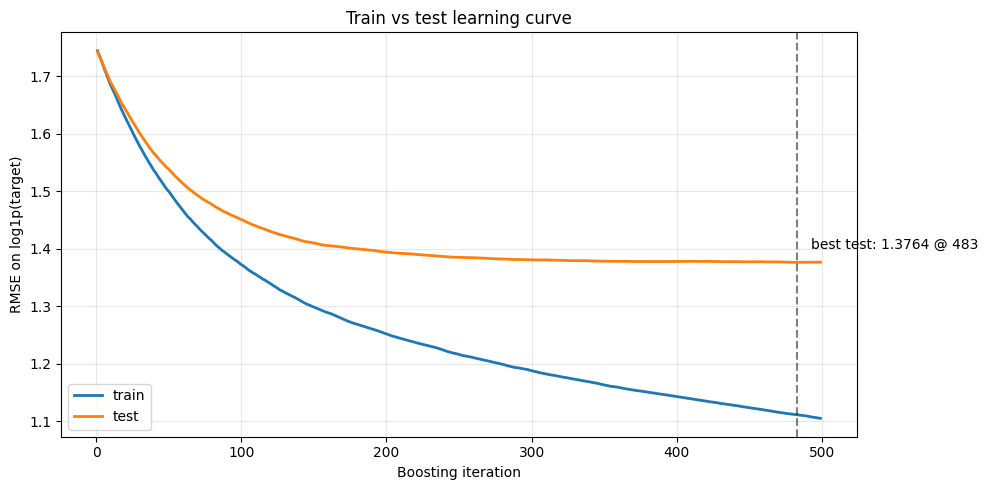

In [14]:
evals_result = final_model.evals_result_
train_curve = evals_result["train"]["rmse"]
test_curve = evals_result["test"]["rmse"]
iterations = np.arange(1, len(train_curve) + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(iterations, train_curve, label="train", linewidth=2)
ax.plot(iterations, test_curve, label="test", linewidth=2)
ax.set_title("Train vs test learning curve")
ax.set_xlabel("Boosting iteration")
ax.set_ylabel("RMSE on log1p(target)")
ax.grid(True, alpha=0.3)
ax.legend()

best_test_iteration = int(np.argmin(test_curve)) + 1
best_test_score = float(np.min(test_curve))
ax.axvline(best_test_iteration, color="black", linestyle="--", alpha=0.5)
ax.annotate(
    f"best test: {best_test_score:.4f} @ {best_test_iteration}",
    xy=(best_test_iteration, best_test_score),
    xytext=(10, 10),
    textcoords="offset points",
)

plt.tight_layout()
plt.show()

## Save Artifacts

In [15]:
trials_df = study.trials_dataframe().sort_values("value")

summary = {
    "target_transform": "log1p",
    "primary_metric": "rmsle",
    "optimizer": "optuna",
    "n_trials": N_TRIALS,
    "cv_folds": CV,
    "test_size": TEST_SIZE,
    "seed": SEED,
    "sparsity_threshold": "none" if SPARSITY_THRESHOLD is None else SPARSITY_THRESHOLD,
    "rowwise_features": [
        "non_zero_count",
        "non_zero_ratio",
        "row_sum",
        "row_mean",
        "row_std",
        "row_max",
        "nz_mean",
        "nz_std",
    ],
    "base_features_kept": len(keep_columns),
    "final_features": X_train_final.shape[1],
    "best_cv_rmsle": float(study.best_value),
    "best_params": best_params,
    "final_params": final_params,
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
    "fold_best_iterations": study.best_trial.user_attrs.get("fold_best_iterations"),
    "train_rmsle": float(train_rmsle),
    "test_rmsle": float(test_rmsle),
    "rmsle_gap_test_minus_train": float(test_rmsle - train_rmsle),
    "train_rmse": float(train_rmse),
    "test_rmse": float(test_rmse),
    "train_mae": float(train_mae),
    "test_mae": float(test_mae),
    "train_r2": float(train_r2),
    "test_r2": float(test_r2),
}

summary

{'target_transform': 'log1p',
 'primary_metric': 'rmsle',
 'optimizer': 'optuna',
 'n_trials': 50,
 'cv_folds': 5,
 'test_size': 0.33,
 'seed': 42,
 'sparsity_threshold': 0.9875,
 'rowwise_features': ['non_zero_count',
  'non_zero_ratio',
  'row_sum',
  'row_mean',
  'row_std',
  'row_max',
  'nz_mean',
  'nz_std'],
 'base_features_kept': 2482,
 'final_features': 2490,
 'best_cv_rmsle': 1.357585405587402,
 'best_params': {'n_estimators': 2535,
  'learning_rate': 0.013234539038264626,
  'num_leaves': 60,
  'max_depth': 6,
  'min_child_samples': 20,
  'subsample': 0.6403124017278968,
  'subsample_freq': 3,
  'colsample_bytree': 0.792621623320577,
  'reg_alpha': 0.0028711731766495052,
  'reg_lambda': 22.77520271012238,
  'min_split_gain': 0.17467332761565313},
 'final_params': {'n_estimators': 499,
  'learning_rate': 0.013234539038264626,
  'num_leaves': 60,
  'max_depth': 6,
  'min_child_samples': 20,
  'subsample': 0.6403124017278968,
  'subsample_freq': 3,
  'colsample_bytree': 0.79262

## How To Read The Result

- Compare `best_cv_rmsle` against the best row-wise sparsity result from notebook `05`.
- The Optuna objective uses early stopping inside CV folds; `final_params["n_estimators"]` comes from the best trial mean CV best iteration, not from the test split.
- Compare `train_rmsle` and `test_rmsle` to inspect overfitting. A large positive `rmsle_gap_test_minus_train` means the final model fits train much better than unseen test data.
- Treat `test_rmsle` as a sanity check, not as the optimization target.
- If this wins, use this configuration as the tuned single-model candidate for final ensembling or repeated-CV validation.

# 09 Final Optuna LGBM Report

## Goal

The goal of this notebook was to run a final Optuna search for LightGBM after fixing the data-side setup: sparse filtering with threshold `0.9875` plus row-wise aggregate features.

## What Was Done

- Loaded the processed data.
- Split the data into train and test parts with `test_size=0.33` and seed `42`.
- Used the sparse threshold `0.9875` selected in notebook `05`.
- Added row-wise aggregate features from notebook `06`.
- Used `log1p(target)` and optimized log-space RMSE, equivalent to RMSLE for this target transform.
- Ran Optuna for `50` trials with 5-fold CV.
- Fitted sparse filtering inside each CV fold to avoid leakage.
- Used early stopping with `100` rounds inside CV folds.
- Set final `n_estimators` from the best trial's mean fold best iteration.
- Trained the final model on the train split and evaluated train/test metrics.

## Main Results

| metric | value |
| --- | ---: |
| Sparse threshold | 0.9875 |
| Base features kept | 2,482 |
| Final features | 2,490 |
| Best CV RMSLE | 1.3576 |
| Train RMSLE | 1.1052 |
| Test RMSLE | 1.3767 |
| RMSLE gap test-train | 0.2715 |
| Train RMSE | 6,837,337.92 |
| Test RMSE | 7,072,245.79 |
| RMSE gap test-train | 234,907.87 |
| Train MAE | 3,620,785.25 |
| Test MAE | 3,963,023.64 |
| Train R2 | 0.3296 |
| Test R2 | 0.2163 |

Best Optuna trial was trial `22` with CV RMSLE `1.3576`. Its searched parameters were:

- `n_estimators`: `2535`
- `learning_rate`: `0.0132345390`
- `num_leaves`: `60`
- `max_depth`: `6`
- `min_child_samples`: `20`
- `subsample`: `0.6403124017`
- `subsample_freq`: `3`
- `colsample_bytree`: `0.7926216233`
- `reg_alpha`: `0.0028711732`
- `reg_lambda`: `22.7752027101`
- `min_split_gain`: `0.1746733276`

Final model parameters used `n_estimators=499`, computed from the best trial's fold best iterations `[489, 516, 484, 465, 543]`.

## Comparison To Notebook 08

| notebook | setup | CV RMSLE | Test RMSLE | Test RMSE | Test MAE | Test R2 |
| --- | --- | ---: | ---: | ---: | ---: | ---: |
| `08_lgbm_tuning_param_per_time.ipynb` | Sequential manual tuning | 1.3571 | 1.3776 | 7,030,480.10 | 3,925,190.76 | 0.2256 |
| `09_final_optuna_lgbm.ipynb` | Optuna, 50 trials | 1.3576 | 1.3767 | 7,072,245.79 | 3,963,023.64 | 0.2163 |

## Conclusion

This 50-trial Optuna run is mixed relative to notebook `08`. It is slightly worse on CV RMSLE (`1.3576` vs `1.3571`) but slightly better on held-out test RMSLE (`1.3767` vs `1.3776`). Raw-scale test metrics are still weaker than notebook `08`: RMSE `7,072,245.79` vs `7,030,480.10`, MAE `3,963,023.64` vs `3,925,190.76`, and R2 `0.2163` vs `0.2256`. The train/test RMSLE gap of `0.2715` and RMSE gap of `234,907.87` indicate meaningful overfitting. Based on this run, notebook `09` gives the best held-out RMSLE by a small margin, while notebook `08` remains stronger on raw-scale metrics and generalization stability.
